# Galaxy Clustering Algorithm!

- Use VFS galaxies! Fortunately, I have not deleted my catalog of galaxies...
- What data?
    - Maybe feed in either CIGALE or GALFIT output parameters?
    - Measure curves of growth??
- Use PCA for dimensionality reduction
- Then...UNSUPERVISED LEARNING! I.E., find natural groupings in the data without pre-defined labels
- And then...interpret. Is there any physical meaning associated with the clusters?
    - Morphology? 
        - May have to perform some visual inspection
        - Could also try statmorph?
    - Environment?
        - vf_v2_environment.fits flags

### To begin, I will need some features
- A few thoughts:
    - NUV-r, FUV-NUV, W1-W3, g-r, W1-W2 colors
    - CIGALE sSFR, Mstar, A_V
    - GALFIT nser (W1), nser (W3), axis ratio (W1), size ratio (W3/W1)
    - W1 luminosity
- Will have to 'standardize' these features for clustering
    - ensures all features contribute equally regardless of their original units and scales

---

## K-means Run

In [1]:
%load_ext autoreload
%autoreload 2

In [50]:
#from galfit_kmeans import galfit_kmeans
from kmeans_pipeline import run_kmeans

import warnings
warnings.filterwarnings("ignore")

#set colors=False to use the default GALFIT set of features (Sersic index, effective radius)
#df_scaled = galfit_kmeans(colors=False)

#colors=True will include the following color magnitudes from JM's SGA2020 photometry:
    # NUV-r
    # W1-W3

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

##############################################################
Removed 4785/6780 galaxies with GALFIT and PHOT quality flags.
##############################################################
IQR clipping (k=1.5): Removing an additional 570/1995 outliers (28.6%)
Remaining galaxies: 1425


A copy of unscaled/scaled galaxy features was written to data/kmeans_feature_data.csv!

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/kmeans_median_features.csv:

##################################################################
Using default layout dictionary for median group feature subplots!
##################################################################


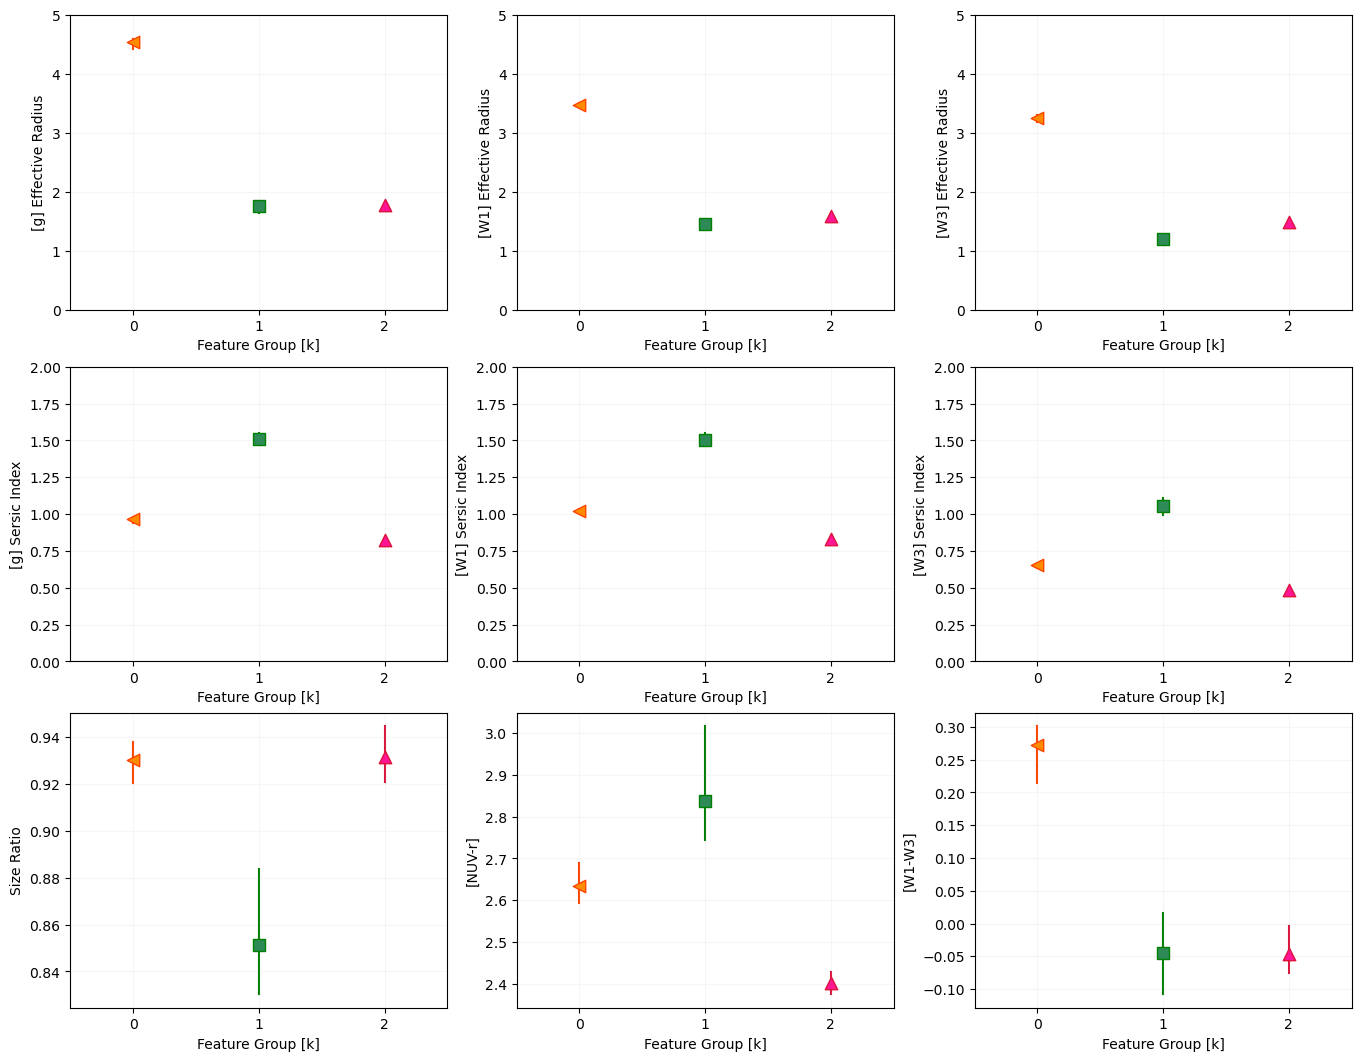

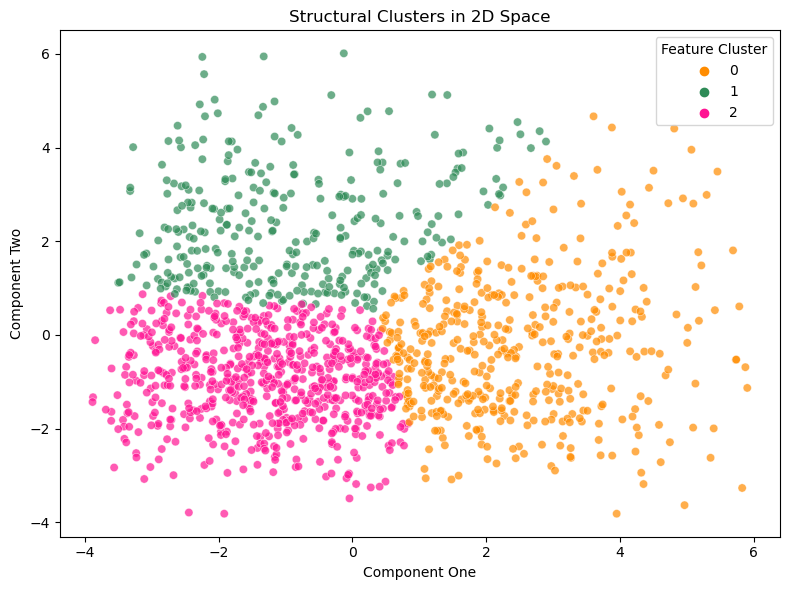

test one: 0.013071895424836596 0.010893246187363842
test one: 0.019169329073482427 0.019169329073482427
test one: 0.010719754977029095 0.009188361408882087
test one: 0.004357298474945533 0.0065359477124183
test one: 0.01597444089456869 0.012779552715654952
test one: 0.0076569678407350725 0.00918836140888208
test one: 0.01307189542483661 0.013071895424836596
test one: 0.019169329073482427 0.019169329073482427
test one: 0.010719754977029095 0.012251148545176102
test one: 0.01742919389978212 0.017429193899782147
test one: 0.019169329073482427 0.019169329073482427
test one: 0.010719754977029095 0.012251148545176116
test one: 0.008714596949891067 0.008714596949891067
test one: 0.012779552715654952 0.012779552715654952
test one: 0.00918836140888208 0.0076569678407350725
test one: 0.019607843137254888 0.019607843137254916
test one: 0.019169329073482427 0.019169329073482427
test one: 0.012251148545176102 0.013782542113323137
test one: 0.010893246187363842 0.010893246187363828
test one: 0.01597

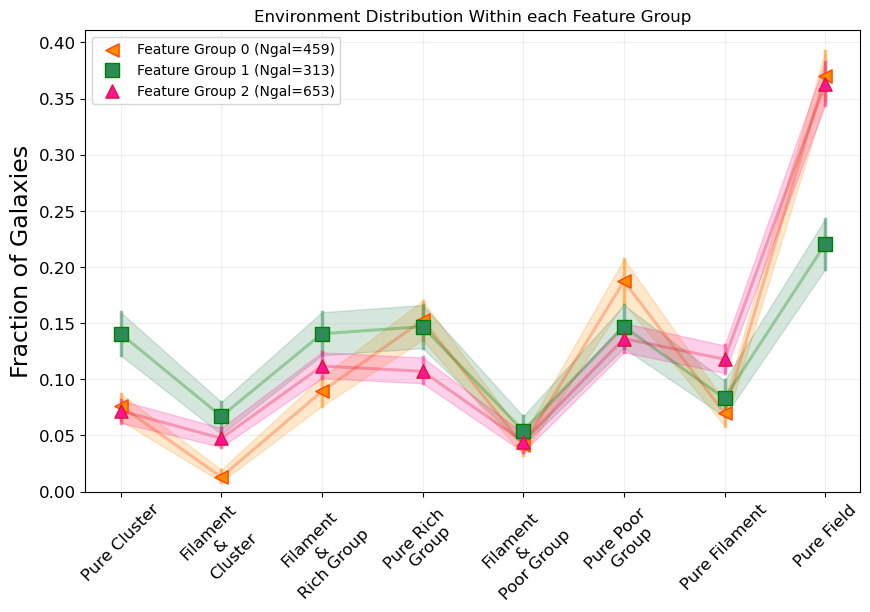

test one: 0.03968253968253971 0.03968253968253965
test one: 0.03968253968253965 0.047619047619047616
test one: 0.03968253968253971 0.047619047619047616
test one: 0.034482758620689655 0.034482758620689655
test one: 0.06896551724137934 0.06896551724137928
test one: 0.06896551724137928 0.06896551724137934
test one: 0.037974683544303806 0.03164556962025317
test one: 0.03797468354430378 0.03797468354430383
test one: 0.03797468354430383 0.03797468354430378
test one: 0.032258064516129004 0.03763440860215056
test one: 0.03225806451612903 0.032258064516129004
test one: 0.03763440860215056 0.03763440860215056
test one: 0.06153846153846154 0.06153846153846154
test one: 0.06153846153846154 0.06153846153846154
test one: 0.06153846153846154 0.061538461538461486
test one: 0.03167420814479638 0.03167420814479638
test one: 0.02714932126696834 0.027149321266968313
test one: 0.03167420814479638 0.03167420814479638
test one: 0.037037037037037035 0.037037037037037035
test one: 0.037037037037037035 0.037037

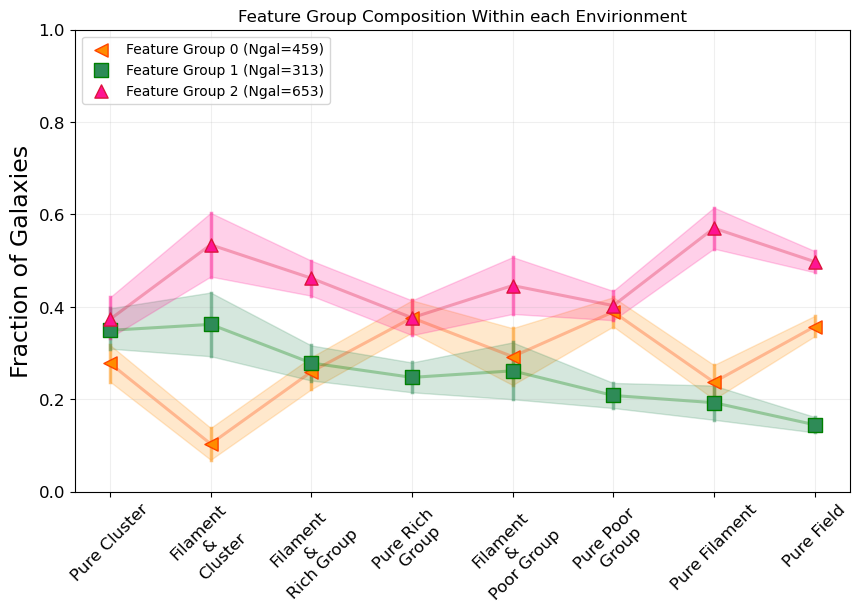

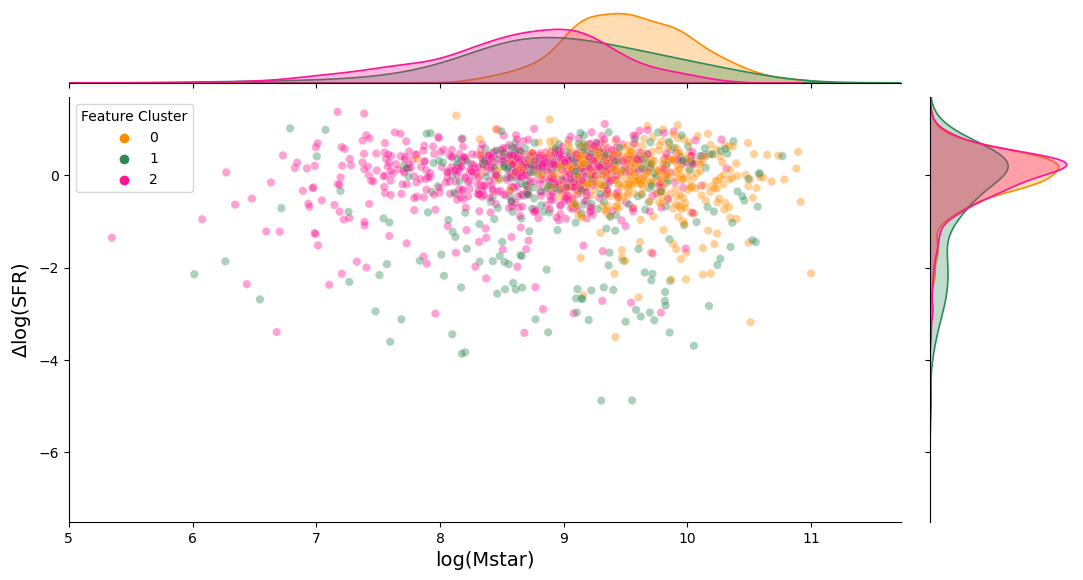

In [51]:
df = run_kmeans(colors=False)

## HDBSCAN Run

In [1]:
from hdbscan_pipeline import run_hdbscan

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

USING THESE FEATURES: ['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
'CN_W2', 'CN_W3-fixBA']

##############################################################
Removed 4785/6780 galaxies with GALFIT and PHOT quality flags.
##############################################################


A copy of the scaled galaxy features was written to data/hdb_feature_data.csv!

A summary of feature cluster median properties saved to 
/Users/k215c316/github/machine-learning/galaxy_feature_clustering/data/hdbscan_median_features.csv:

##################################################################
Using default layout dictionary for median group feature subplots!
##################################################################


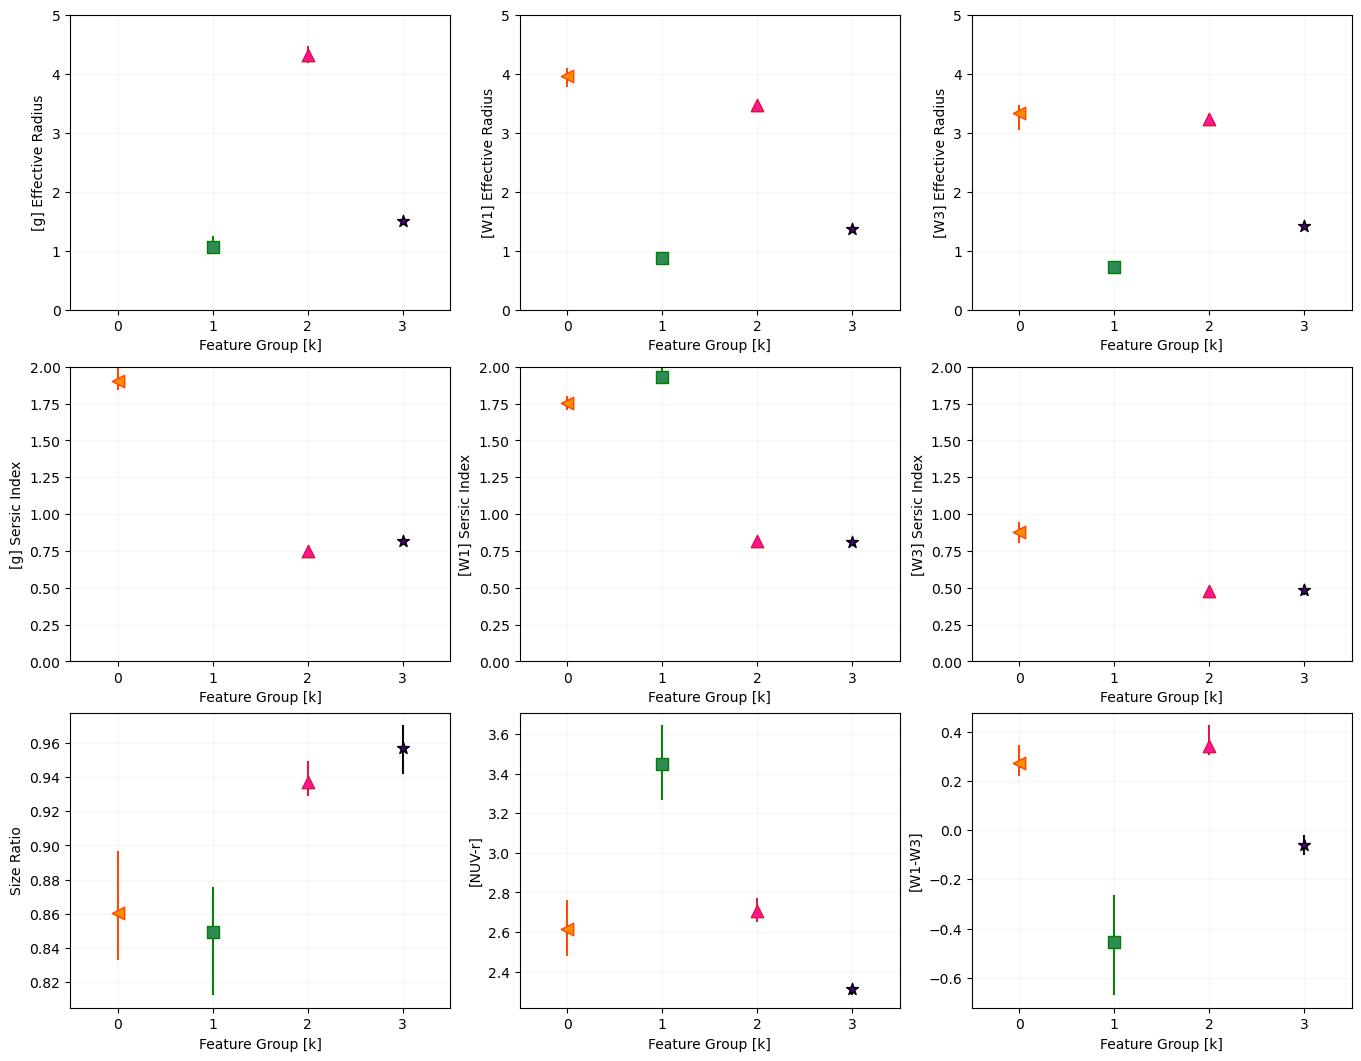

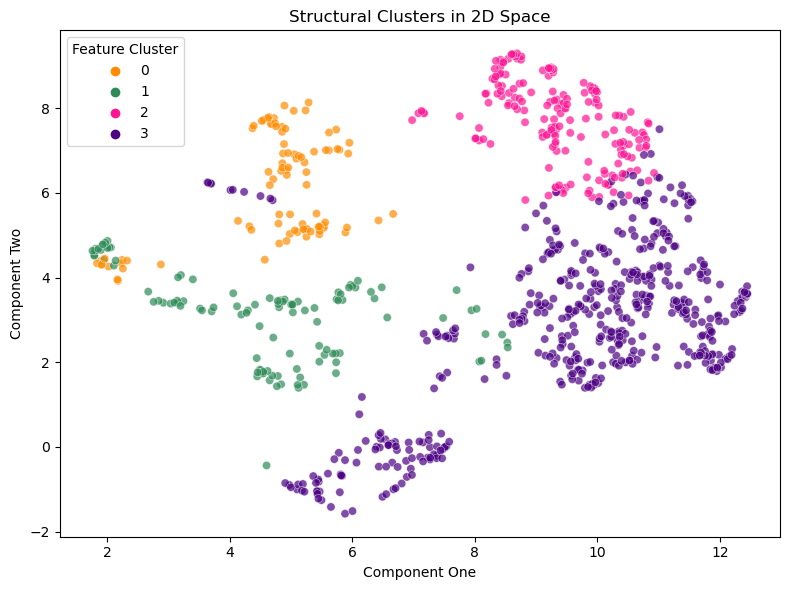

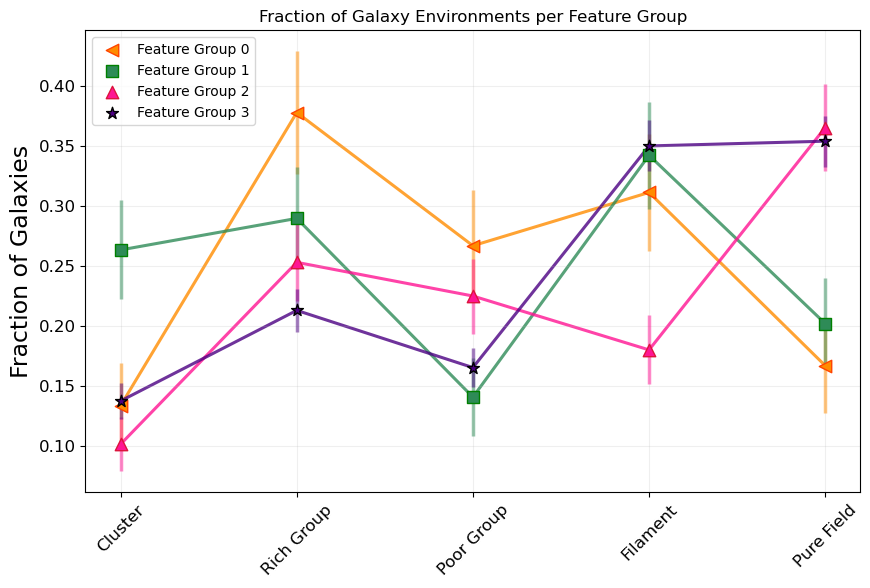

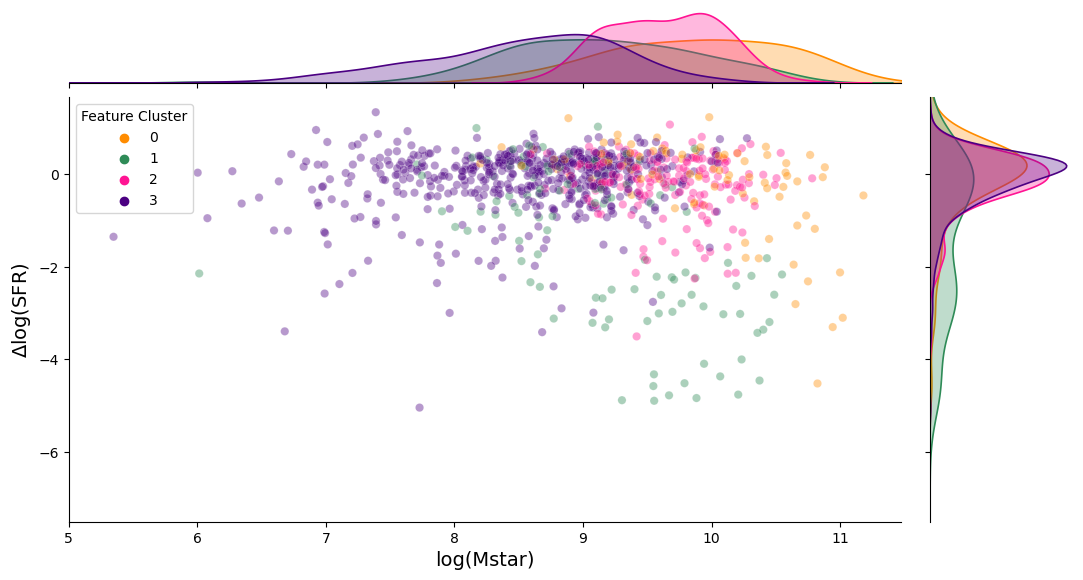

In [2]:
import warnings
warnings.filterwarnings("ignore")

df_scaled = run_hdbscan(colors=False)

## Testbed

In [3]:
import sys
sys.path.insert(0,'utils')
from clustering_utils import run1_hdbscan, umap_2d, find_optimal_hdbparams
from plotting_utils import plot_clusters, plot_corner, plot_env_fraction, plot_group_features, plot_sfrmstar

import warnings
warnings.filterwarnings("ignore")

In [38]:
import pandas as pd
df = pd.read_csv('data/hdb_feature_data.csv')
#features=['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
#          'CN_W2', 'CN_W3-fixBA']
features=['CRE_g', 'CRE_r', 'CRE_W1-fixBA', 'CRE_W2', 'CRE_W3-fixBA', 'CN_g', 'CN_r', 'CN_W1-fixBA', 
         'CN_W2', 'CN_W3-fixBA']

In [39]:
%load_ext autoreload
%autoreload 2

In [40]:
best=find_optimal_hdbparams(df, features,
                           min_cluster_sizes=[20,30,40,50,60,100],
                           min_samples_list=[10,15,20,30,50,60,100,'same'],
                           metrics=['euclidean', 'manhattan', 'canberra'],
                           cluster_methods=['eom','leaf'])

HDBSCAN DBCV sweep:   0%|          | 0/288 [00:00<?, ?it/s]

############################
 Best parameters (DBCV):
   min_cluster_size         = 20
   min_samples              = 100
   metric                   = canberra
   cluster_selection_method = eom
   DBCV score               = -0.219
############################


In [41]:
min_cluster_size = best[0]
min_samples = best[1]
metric = best[2]
cluster_selection_method = best[3]

In [42]:
#perform HDBSCAN on the full set of features, using the parameters defined above.

feature_data = run1_hdbscan(df, features, min_cluster_size=80, min_samples=3,
                           metric='canberra', cluster_selection_method='eom')

#feature_data = run1_hdbscan(df_scaled, features, min_cluster_size=min_cluster_size, min_samples=min_samples,
#                           metric=metric, cluster_selection_method=cluster_selection_method)

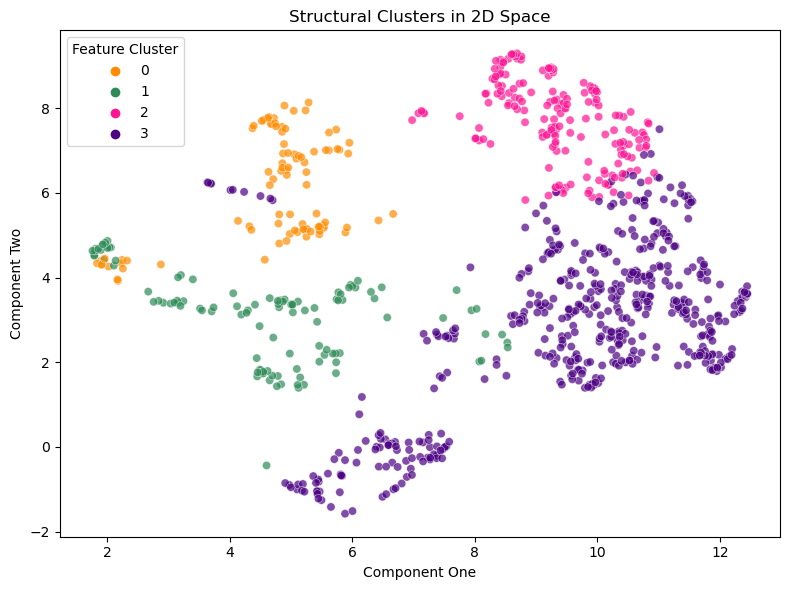

In [43]:
#create the Comp1, Comp2 columns. IGNORES 'Feature Cluster' column!
feature_data_umap = umap_2d(feature_data, features)

#plort.
plot_clusters(feature_data_umap[feature_data['Feature Cluster']!=-1], UMAP=True) #x='CRE_W1-fixBA_unscaled', y='CRE_W3-fixBA_unscaled')

In [44]:
#plot_env_fraction(feature_data[feature_data['Feature Cluster']!=-1], main_only=True)

In [46]:
from table_utils import create_median_table
summary_rows = create_median_table(feature_data[feature_data['Feature Cluster']!=-1], features)
cluster_summary = pd.DataFrame(summary_rows)

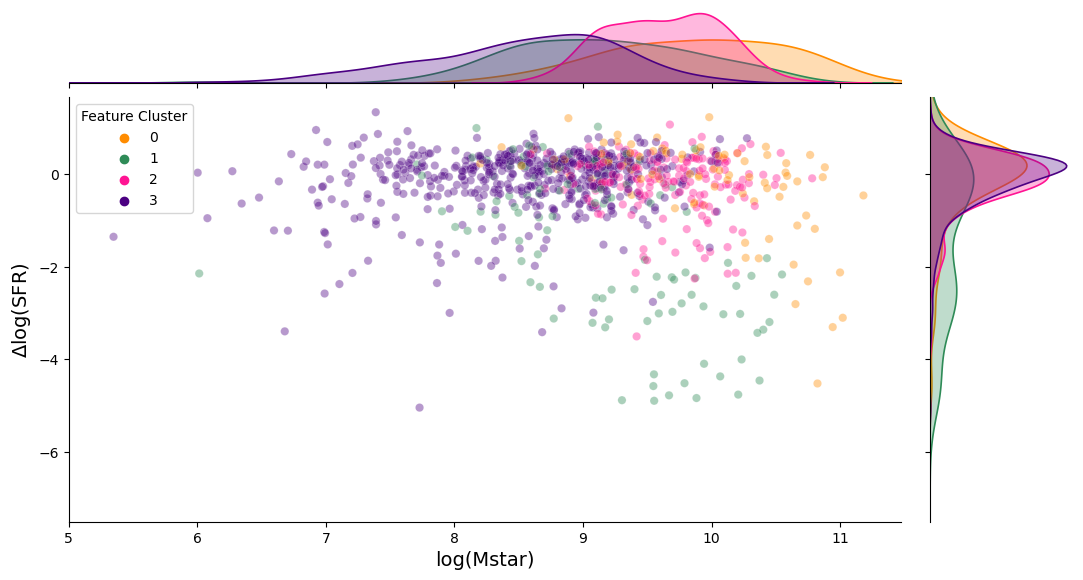

In [47]:
plot_sfrmstar(feature_data[feature_data['Feature Cluster']!=-1])